# Sonar Tracker Evaluation — Plots from cached .txt files

Loads pre-computed inference `.txt` files instead of re-running inference.

**Model:** `yolov26s_sonar_improved_c`
**Classes:** fish (class_id = 1) · net (class_id = 2)
**Trackers:** ByteTrack, BOT-SORT

Run from `tracking/` directory.

In [ ]:
print("Jupyter OK!")

In [ ]:
import sys
sys.path.insert(0, "..")

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from tracking.utils.mot_metrics import (
    load_gt, img_dir_for, frame_map, collect_images,
    compute_metrics, compute_hota, build_summary_table,
    plot_metrics_bar, plot_error_breakdown,
    plot_track_comparison, plot_det_timeline, plot_id_switches,
    _iou_matrix_xywh,
)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.spines.top": True, "axes.spines.right": True})


def clean_fig(fig):
    """Remove all titles; keep axis box intact."""
    fig.suptitle("")
    for ax in fig.axes:
        ax.set_title("")
    return fig

# ── Sonar physical mapping ─────────────────────────────────────────────────────
S_W, S_H  = 1200, 700
S_YMAX_M  = 20.0
S_XSPAN_M = S_YMAX_M * np.sin(np.deg2rad(45.0))
S_DX = 2 * S_XSPAN_M / S_W
S_DY = S_YMAX_M / S_H

def sonar_px_to_m(cx, cy):
    x_m = cx * S_DX - S_XSPAN_M
    y_m = (S_H - cy) * S_DY
    return x_m, y_m, np.sqrt(x_m**2 + y_m**2)

In [ ]:
REPO       = Path("..").resolve()
SONAR_ROOT = REPO / "data-processing" / "sonar" / "MOT"

SELECTED_SEQUENCES = [
    "2024-08-20_14-31-29",
    "2024-08-20_17-34-52",
    "2024-08-20_17-39-32",
    "2024-08-20_17-40-54",
    "2024-08-20_17-55-40",
]

IOU_MATCH      = 0.5
TRACKERS       = ["bytetrack", "botsort"]
MODEL_NAME     = "yolov26s_sonar_improved_c"
MOT_OUTPUT_DIR = Path("outputs/inference_annotation_MOT11")

all_seqs  = sorted([p.name for p in SONAR_ROOT.iterdir() if p.is_dir()])
SEQUENCES = [s for s in all_seqs if s in SELECTED_SEQUENCES] if SELECTED_SEQUENCES else all_seqs

print(f"Model name : {MODEL_NAME}")
print(f"Trackers   : {TRACKERS}")
print(f"Sequences ({len(SEQUENCES)}):")
for s in SEQUENCES:
    print(f"  {s}")

## 1  Load GT + cached inference

In [ ]:
def load_mot_txt(txt_path, img_dir):
    """Load a MOT11-format inference .txt and map frame_id -> frame_norm."""
    cols = ["frame_id", "track_id", "x", "y", "w", "h",
            "not_ignored", "class_id", "visibility"]
    df = pd.read_csv(txt_path, header=None, names=cols)
    ts_fn = frame_map(img_dir)
    df["frame_id"]   = df["frame_id"].astype(np.int64)
    df["frame_norm"] = df["frame_id"].map(ts_fn)
    df = df.dropna(subset=["frame_norm"]).copy()
    df["frame_norm"] = df["frame_norm"].astype(int)
    return df.reset_index(drop=True)

# ── Load GT (all classes) ─────────────────────────────────────────────────────
gt_all       = {}
total_frames = {}

for seq in SEQUENCES:
    seq_path          = SONAR_ROOT / seq
    idir              = img_dir_for(seq_path, "sonar")
    gt_all[seq]       = load_gt(seq_path / "gt" / "gt.txt", idir)
    total_frames[seq] = len(list(idir.glob("*.jpg")))

# ── Load predictions from cached .txt files ───────────────────────────────────
pred_by_tracker = {}
for tracker in TRACKERS:
    pred_by_tracker[tracker] = {}
    for seq in SEQUENCES:
        idir     = img_dir_for(SONAR_ROOT / seq, "sonar")
        txt_name = f"INFERENCE_MOT11_SONAR_{seq}_{MODEL_NAME}+{tracker}.txt"
        txt_path = MOT_OUTPUT_DIR / txt_name
        pred     = load_mot_txt(txt_path, idir)
        pred_by_tracker[tracker][seq] = pred
        for cls, name in [(1, "fish"), (2, "net")]:
            ng  = (gt_all[seq]["class_id"] == cls).sum()
            np_ = (pred["class_id"] == cls).sum() if not pred.empty else 0
            print(f"  {tracker} / {seq[-8:]}  {name}: GT={ng}  Pred={np_}")

## 2  Compute metrics — fish (class 1)

In [ ]:
accs_fish_by_tracker    = {}
results_fish_by_tracker = {}

for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    accs_fish = {}
    res_fish  = {}
    for seq in SEQUENCES:
        gt_f   = gt_all[seq][gt_all[seq]["class_id"] == 1].copy()
        pred_f = pred_by_tracker[tracker][seq]
        pred_f = pred_f[pred_f["class_id"] == 1].copy() if not pred_f.empty else pred_f
        acc, summary = compute_metrics(gt_f, pred_f, iou_threshold=IOU_MATCH)
        hota         = compute_hota(gt_f, pred_f)
        for k, v in hota.items():
            summary[k] = v
        accs_fish[seq] = acc
        res_fish[seq]  = summary
    accs_fish_by_tracker[tracker]    = accs_fish
    results_fish_by_tracker[tracker] = res_fish

    print(f"\n── {tracker.upper()} — Fish metrics ──")
    for seq in SEQUENCES:
        h = res_fish[seq]
        print(f"  {seq[-8:]}  "
              f"HOTA={float(h['hota'].iloc[0])*100:.1f}%  "
              f"MOTA={float(h['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(h['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(h['num_switches'].iloc[0])}")
    display(build_summary_table(res_fish))

## 3  Compute metrics — net (class 2)

In [ ]:
accs_net_by_tracker    = {}
results_net_by_tracker = {}

for tracker in TRACKERS:
    run_tag  = f"{MODEL_NAME}+{tracker}"
    accs_net = {}
    res_net  = {}
    for seq in SEQUENCES:
        gt_n   = gt_all[seq][gt_all[seq]["class_id"] == 2].copy()
        pred_n = pred_by_tracker[tracker][seq]
        pred_n = pred_n[pred_n["class_id"] == 2].copy() if not pred_n.empty else pred_n
        if gt_n.empty:
            print(f"{seq[-8:]}: no net GT — skipping")
            continue
        acc, summary = compute_metrics(gt_n, pred_n, iou_threshold=IOU_MATCH)
        hota         = compute_hota(gt_n, pred_n)
        for k, v in hota.items():
            summary[k] = v
        accs_net[seq] = acc
        res_net[seq]  = summary
    accs_net_by_tracker[tracker]    = accs_net
    results_net_by_tracker[tracker] = res_net

    if res_net:
        print(f"\n── {tracker.upper()} — Net metrics ──")
        for seq in res_net:
            h = res_net[seq]
            print(f"  {seq[-8:]}  "
                  f"HOTA={float(h['hota'].iloc[0])*100:.1f}%  "
                  f"MOTA={float(h['mota'].iloc[0])*100:.1f}%  "
                  f"IDF1={float(h['idf1'].iloc[0])*100:.1f}%  "
                  f"IDSW={int(h['num_switches'].iloc[0])}")
        display(build_summary_table(res_net))

## 4  Compute metrics — combined fish + net

In [ ]:
results_comb_by_tracker = {}
accs_comb_by_tracker    = {}

for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    accs_comb = {}
    res_comb  = {}
    for seq in SEQUENCES:
        gt_c   = gt_all[seq].copy()
        pred_c = pred_by_tracker[tracker][seq].copy()
        if gt_c.empty:
            continue
        acc, summary = compute_metrics(gt_c, pred_c, iou_threshold=IOU_MATCH)
        hota         = compute_hota(gt_c, pred_c)
        for k, v in hota.items():
            summary[k] = v
        accs_comb[seq] = acc
        res_comb[seq]  = summary
    accs_comb_by_tracker[tracker]    = accs_comb
    results_comb_by_tracker[tracker] = res_comb

    print(f"\n── {tracker.upper()} — Combined (fish + net) ──")
    for seq in res_comb:
        h = res_comb[seq]
        print(f"  {seq[-8:]}  "
              f"HOTA={float(h['hota'].iloc[0])*100:.1f}%  "
              f"MOTA={float(h['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(h['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(h['num_switches'].iloc[0])}")
    display(build_summary_table(res_comb))

## 5  Metrics bar charts — fish

In [ ]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_metrics_bar(results_fish_by_tracker[tracker],
                           metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                           title="")
    clean_fig(fig)
    plt.tight_layout()
    plt.savefig(f"outputs/sonar_{run_tag}_fish_metrics_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6  Metrics bar charts — net

In [ ]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    res_net = results_net_by_tracker[tracker]
    if res_net:
        fig = plot_metrics_bar(res_net,
                               metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                               title="")
        clean_fig(fig)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{tracker}: No net GT found.")

## 7  Error breakdown — fish

In [ ]:
for tracker in TRACKERS:
    fig = plot_error_breakdown(results_fish_by_tracker[tracker], title="")
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

## 8  GT vs predicted track counts — fish

In [ ]:
for tracker in TRACKERS:
    gt_fish   = {s: gt_all[s][gt_all[s]["class_id"] == 1].copy() for s in SEQUENCES}
    pred_fish = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 1].copy()
                 if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                 for s in SEQUENCES}
    fig = plot_track_comparison(gt_fish, pred_fish)
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

## 9  Detection count per frame — GT vs predicted (fish)

In [ ]:
for tracker in TRACKERS:
    gt_fish   = {s: gt_all[s][gt_all[s]["class_id"] == 1].copy() for s in SEQUENCES}
    pred_fish = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 1].copy()
                 if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                 for s in SEQUENCES}
    fig = plot_det_timeline(gt_fish, pred_fish, total_frames, title="")
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

## 10  Cumulative ID switches — fish

In [ ]:
for tracker in TRACKERS:
    fig = plot_id_switches(accs_fish_by_tracker[tracker], total_frames, title="")
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

## 11  Net range error (sonar physical space)

In [ ]:
def add_range_m(df):
    cx = df["x"] + df["w"] / 2
    cy = df["y"] + df["h"] / 2
    _, _, rng = sonar_px_to_m(cx, cy)
    df = df.copy()
    df["range_m"] = rng
    return df

for tracker in TRACKERS:
    run_tag  = f"{MODEL_NAME}+{tracker}"
    gt_net   = {s: gt_all[s][gt_all[s]["class_id"] == 2].copy() for s in SEQUENCES}
    pred_net = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 2].copy()
                if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                for s in SEQUENCES}

    fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(13, 3.5 * len(SEQUENCES)))
    if len(SEQUENCES) == 1:
        axes = [axes]

    for ax, seq in zip(axes, SEQUENCES):
        gn = add_range_m(gt_net.get(seq, pd.DataFrame()))
        pn = add_range_m(pred_net.get(seq, pd.DataFrame()))

        if gn.empty:
            ax.set_visible(False)
            continue

        gt_r = gn.groupby("frame_norm")["range_m"].median()
        ax.plot(gt_r.index, gt_r.values, lw=1.4, color="#2E7D32", label="GT net range")

        if not pn.empty:
            pr_r = pn.groupby("frame_norm")["range_m"].median()
            ax.plot(pr_r.index, pr_r.values, lw=1.4, color="#1565C0", ls="--",
                    label="Pred net range")
            merged = gt_r.rename("gt").to_frame().join(pr_r.rename("pr"), how="inner")
            err = (merged["pr"] - merged["gt"]).abs()
            ax2 = ax.twinx()
            ax2.fill_between(err.index, err.values, alpha=0.15, color="#FF9800")
            ax2.plot(err.index, err.values, lw=0.8, color="#FF9800",
                     label=f"abs error (mean={err.mean():.2f} m)")
            ax2.set_ylabel("|error| (m)", color="#FF9800", fontsize=8)
            ax2.tick_params(axis="y", colors="#FF9800")
            ax2.spines[["top", "bottom", "left"]].set_visible(False)
            h2, l2 = ax2.get_legend_handles_labels()
        else:
            h2, l2 = [], []

        ax.set_ylabel("Range (m)")
        ax.set_ylim(bottom=0)
        h1, l1 = ax.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")
        ax.text(0.01, 0.95, seq[-8:], transform=ax.transAxes, fontsize=9, va="top")

    axes[-1].set_xlabel("Frame number")
    plt.tight_layout()
    plt.show()

## 12  MT / PT / ML breakdown — fish

In [ ]:
for tracker in TRACKERS:
    res_fish  = results_fish_by_tracker[tracker]
    seq_names = list(res_fish.keys())
    mt_vals   = [int(res_fish[s]["mostly_tracked"].iloc[0])    for s in seq_names]
    pt_vals   = [int(res_fish[s]["partially_tracked"].iloc[0]) for s in seq_names]
    ml_vals   = [int(res_fish[s]["mostly_lost"].iloc[0])       for s in seq_names]

    x = np.arange(len(seq_names))
    fig, ax = plt.subplots(figsize=(7, 4))
    w = 0.6
    ax.bar(x, mt_vals, width=w, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
    ax.bar(x, pt_vals, width=w, bottom=mt_vals, label="PT (20–80%)", color="#FFA726", edgecolor="white")
    ax.bar(x, ml_vals, width=w, bottom=[m+p for m,p in zip(mt_vals,pt_vals)],
           label="ML (<20%)", color="#EF5350", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([s[-8:] for s in seq_names], rotation=12, ha="right", fontsize=8)
    ax.set_ylabel("Number of GT tracks")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 13  Combined — all sequences
Aggregates all sequences per tracker. Shows combined fish, net, and all-class results.

In [ ]:
_OFF = 10_000

def _stack(dfs_dict):
    frames = []
    for i, (seq, df) in enumerate(dfs_dict.items()):
        if df.empty:
            continue
        frames.append(df.assign(frame_norm=df["frame_norm"] + i * _OFF,
                                track_id  =df["track_id"]   + i * _OFF))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

for tracker in TRACKERS:
    run_tag  = f"{MODEL_NAME}+{tracker}"
    res_fish = results_fish_by_tracker[tracker]
    res_net  = results_net_by_tracker[tracker]
    res_comb = results_comb_by_tracker[tracker]

    gt_fish_d   = {s: gt_all[s][gt_all[s]["class_id"] == 1].copy() for s in SEQUENCES}
    pred_fish_d = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 1].copy()
                   if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                   for s in SEQUENCES}
    gt_net_d    = {s: gt_all[s][gt_all[s]["class_id"] == 2].copy() for s in SEQUENCES}
    pred_net_d  = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 2].copy()
                   if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                   for s in SEQUENCES}

    print(f"\n{'='*60}\n  TRACKER: {tracker.upper()}\n{'='*60}")

    # ── Fish combined ─────────────────────────────────────────────────────────
    gt_fish_comb   = _stack(gt_fish_d)
    pred_fish_comb = _stack(pred_fish_d)
    _, summ_fish_comb = compute_metrics(gt_fish_comb, pred_fish_comb, iou_threshold=IOU_MATCH)
    hota_fish_comb    = compute_hota(gt_fish_comb, pred_fish_comb)
    for k, v in hota_fish_comb.items():
        summ_fish_comb[k] = v
    print(f"Fish combined: HOTA={hota_fish_comb['hota']*100:.1f}%  "
          f"MOTA={float(summ_fish_comb['mota'].iloc[0])*100:.1f}%  "
          f"IDF1={float(summ_fish_comb['idf1'].iloc[0])*100:.1f}%  "
          f"IDSW={int(summ_fish_comb['num_switches'].iloc[0])}")
    results_fish_all = dict(res_fish) | {"COMBINED": summ_fish_comb}
    display(build_summary_table(results_fish_all))

    fig = plot_metrics_bar(
        results_fish_all,
        metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
        title="",
    )
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

    _seq_all = list(results_fish_all.keys())
    _mt = [int(results_fish_all[s]["mostly_tracked"].iloc[0])    for s in _seq_all]
    _pt = [int(results_fish_all[s]["partially_tracked"].iloc[0]) for s in _seq_all]
    _ml = [int(results_fish_all[s]["mostly_lost"].iloc[0])       for s in _seq_all]
    x = np.arange(len(_seq_all))
    fig, ax = plt.subplots(figsize=(max(7, len(_seq_all) * 1.5), 4))
    w = 0.6
    ax.bar(x, _mt, width=w, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
    ax.bar(x, _pt, width=w, bottom=_mt, label="PT (20–80%)", color="#FFA726", edgecolor="white")
    ax.bar(x, _ml, width=w, bottom=[m + p for m, p in zip(_mt, _pt)],
           label="ML (<20%)", color="#EF5350", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([s[-8:] for s in _seq_all], rotation=12, ha="right", fontsize=8)
    ax.set_ylabel("Number of GT tracks")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── Net combined ──────────────────────────────────────────────────────────
    gt_net_comb   = _stack(gt_net_d)
    pred_net_comb = _stack(pred_net_d)
    if not gt_net_comb.empty:
        _, summ_net_comb = compute_metrics(gt_net_comb, pred_net_comb, iou_threshold=IOU_MATCH)
        hota_net_comb    = compute_hota(gt_net_comb, pred_net_comb)
        for k, v in hota_net_comb.items():
            summ_net_comb[k] = v
        print(f"Net combined: HOTA={hota_net_comb['hota']*100:.1f}%  "
              f"MOTA={float(summ_net_comb['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(summ_net_comb['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(summ_net_comb['num_switches'].iloc[0])}")
        results_net_all = dict(res_net) | {"COMBINED": summ_net_comb}
        display(build_summary_table(results_net_all))
        fig = plot_metrics_bar(
            results_net_all,
            metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
            title="",
        )
        clean_fig(fig)
        plt.tight_layout()
        plt.show()

    # ── All-class combined ────────────────────────────────────────────────────
    gt_all_comb   = _stack({s: gt_all[s] for s in SEQUENCES})
    pred_all_comb = _stack(pred_by_tracker[tracker])
    if not gt_all_comb.empty:
        _, summ_all_comb = compute_metrics(gt_all_comb, pred_all_comb, iou_threshold=IOU_MATCH)
        hota_all_comb    = compute_hota(gt_all_comb, pred_all_comb)
        for k, v in hota_all_comb.items():
            summ_all_comb[k] = v
        print(f"All-class combined: HOTA={hota_all_comb['hota']*100:.1f}%  "
              f"MOTA={float(summ_all_comb['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(summ_all_comb['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(summ_all_comb['num_switches'].iloc[0])}")
        results_all_seqs = dict(res_comb) | {"COMBINED": summ_all_comb}
        display(build_summary_table(results_all_seqs))
        fig = plot_metrics_bar(
            results_all_seqs,
            metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
            title="",
        )
        clean_fig(fig)
        plt.tight_layout()
        plt.show()

## V  GT vs Inference — auto-selected examples
Change `CMP_TRACKER`, `COMPARE_SEQ`, `COMPARE_CLASS` (1=fish / 2=net) to explore.

Sequence : 2024-08-20_17-34-52   Tracker : bytetrack   Class : fish
Searching for best FP / FN / TP example frames ...

───────────────────────────────────────────────────────
  TP example  |  seq 17-34-52  frame 571  [bytetrack]  (fish)
  TP=6  FP=0  FN=0  GT boxes=6  Pred boxes=6
  Green = GT    Red = Inference  Orange circle = FP    Blue dashed = net GT
───────────────────────────────────────────────────────


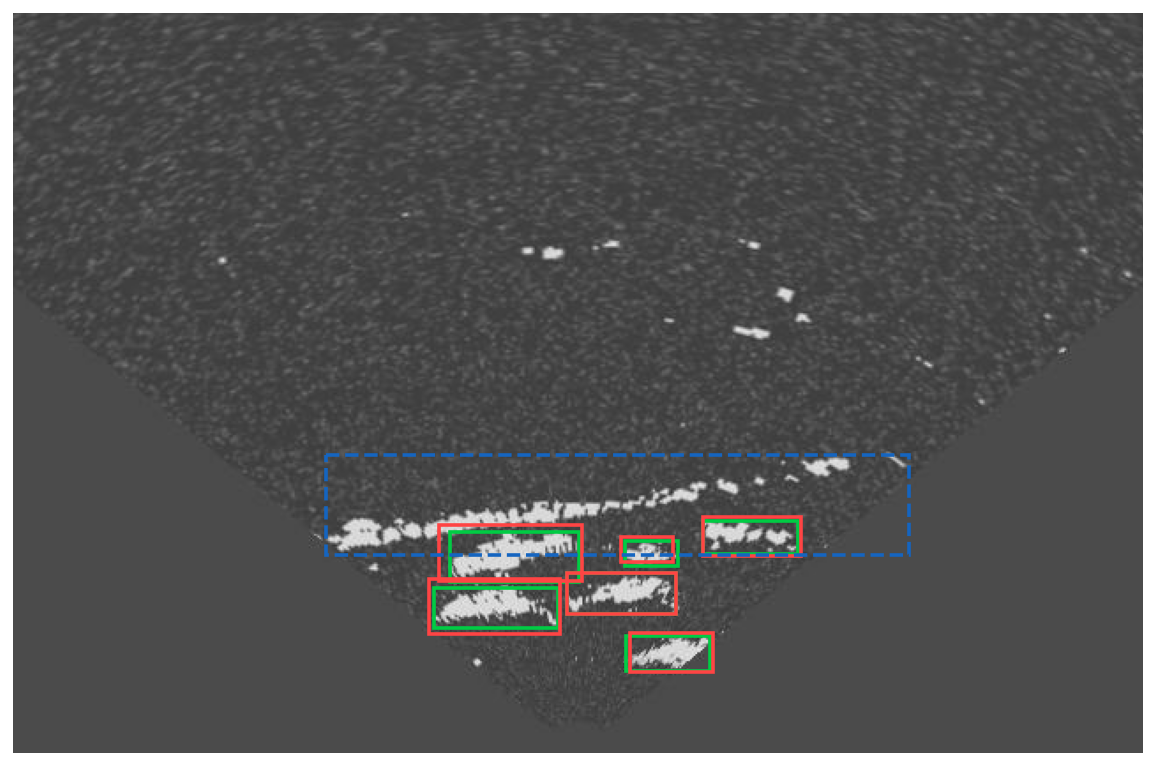


───────────────────────────────────────────────────────
  FN example  |  seq 17-34-52  frame 584  [bytetrack]  (fish)
  TP=0  FP=1  FN=7  GT boxes=7  Pred boxes=1
  Green = GT    Red = Inference  Orange circle = FP    Blue dashed = net GT
───────────────────────────────────────────────────────


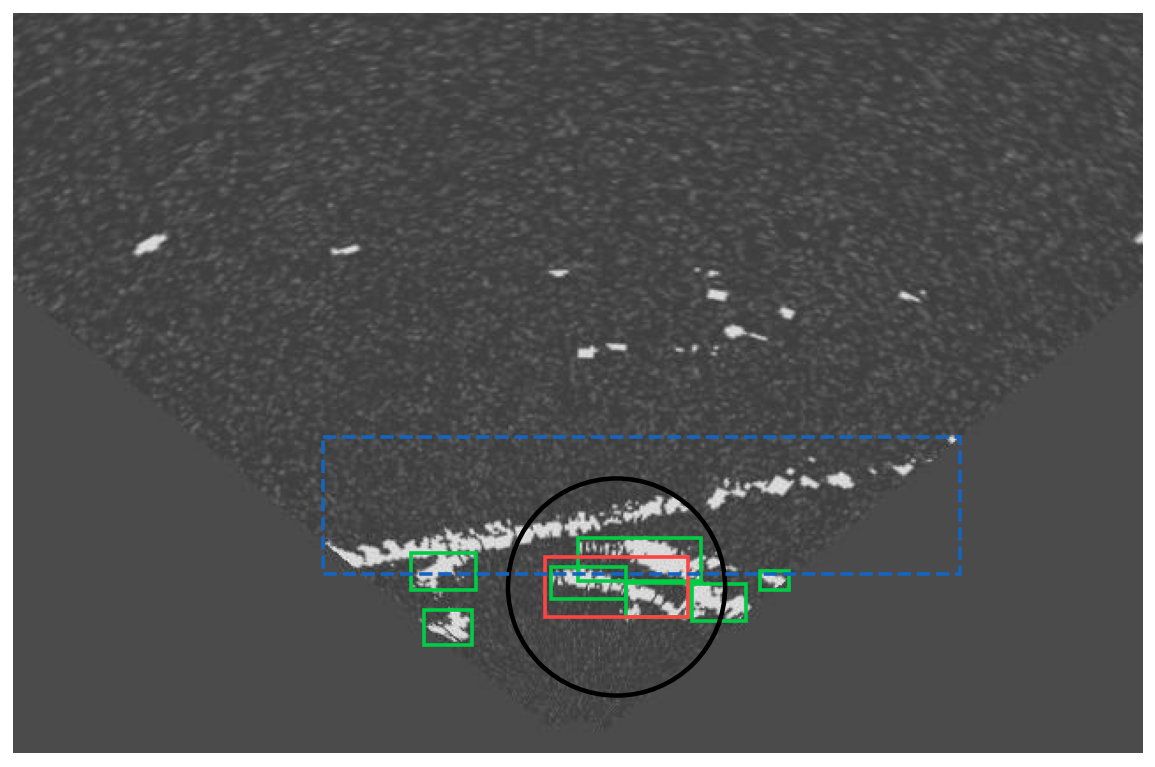


───────────────────────────────────────────────────────
  FP example  |  seq 17-34-52  frame 9  [bytetrack]  (fish)
  TP=0  FP=2  FN=2  GT boxes=2  Pred boxes=2
  Green = GT    Red = Inference  Orange circle = FP    Blue dashed = net GT
───────────────────────────────────────────────────────


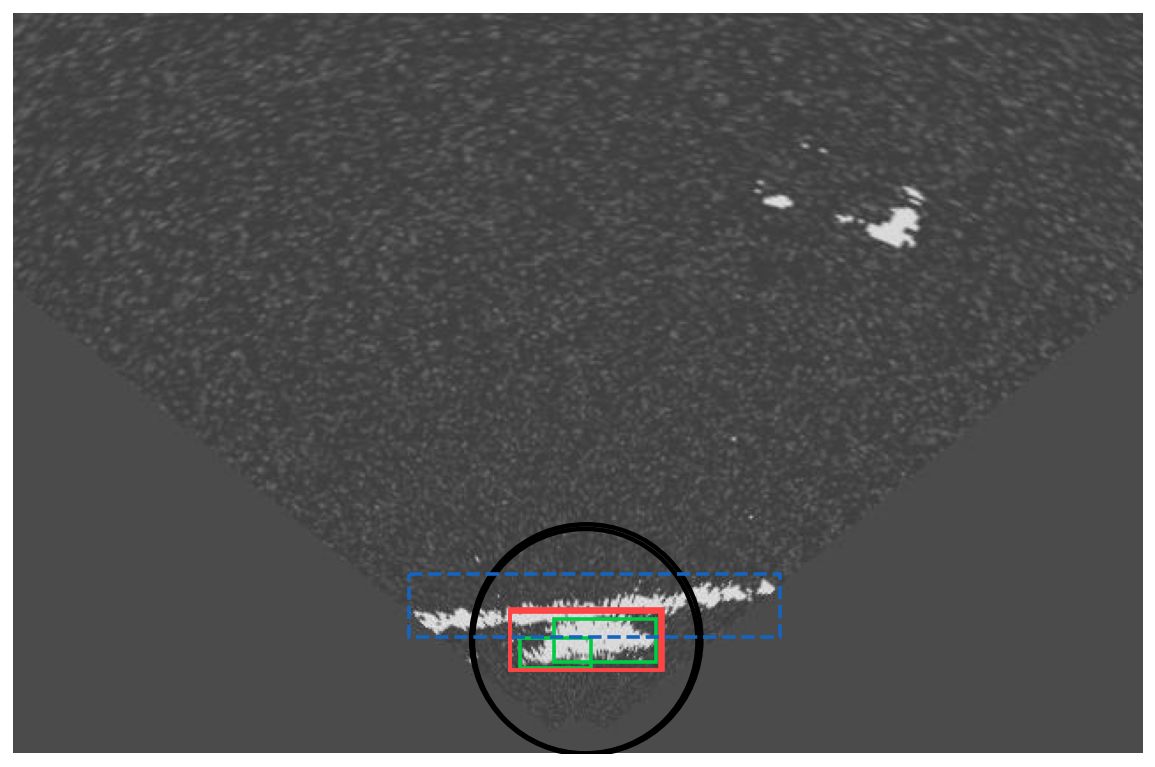

In [115]:
def _frame_match(gt_df_f, pred_df_f, iou_thresh=0.5):
    """Match GT and pred boxes for one frame via greedy IoU.
    Returns (n_tp, n_fp, n_fn, matched_gt_set, matched_pred_set)."""
    gt_arr   = gt_df_f[["x","y","w","h"]].values if len(gt_df_f) > 0 else np.empty((0,4))
    pred_arr = pred_df_f[["x","y","w","h"]].values if len(pred_df_f) > 0 else np.empty((0,4))
    n_gt, n_pred = len(gt_arr), len(pred_arr)
    if n_gt == 0 and n_pred == 0:
        return 0, 0, 0, set(), set()
    if n_gt == 0:
        return 0, n_pred, 0, set(), set(range(n_pred))
    if n_pred == 0:
        return 0, 0, n_gt, set(), set()
    iou   = _iou_matrix_xywh(gt_arr, pred_arr)
    pairs = sorted([(iou[i,j], i, j) for i in range(n_gt) for j in range(n_pred)], reverse=True)
    mg, mp = set(), set()
    for score, i, j in pairs:
        if score < iou_thresh: break
        if i in mg or j in mp: continue
        mg.add(i); mp.add(j)
    return len(mg), n_pred - len(mp), n_gt - len(mg), mg, mp


def _find_examples(gt_df, pred_df, fn_to_img, iou_thresh=0.5):
    """Scan all frames; return best frame_norm for FP-heavy, FN-heavy, TP-clean."""
    frames = sorted(set(gt_df["frame_norm"].unique()) | set(pred_df["frame_norm"].unique()))
    best = {"fp": (0, None), "fn": (0, None), "tp": (0, None)}
    for fn in frames:
        if fn not in fn_to_img:
            continue
        gt_f   = gt_df[gt_df["frame_norm"] == fn]
        pred_f = pred_df[pred_df["frame_norm"] == fn]
        n_tp, n_fp, n_fn, _, _ = _frame_match(gt_f, pred_f, iou_thresh)
        # FP focus: maximise FPs with at least some GT context
        if n_fp > best["fp"][0] and n_tp + n_fn >= 1:
            best["fp"] = (n_fp, fn)
        # FN focus: maximise FNs with at least some predictions present
        if n_fn > best["fn"][0] and n_tp + n_fp >= 1:
            best["fn"] = (n_fn, fn)
        # TP focus: most TPs with fewest errors and at least 3 boxes
        tp_score = n_tp - n_fp - n_fn
        if tp_score > best["tp"][0] and n_tp >= 3:
            best["tp"] = (tp_score, fn)
    return best["fp"][1], best["fn"][1], best["tp"][1]


FP_CIRCLE_COLOR = "#000000"   # orange ring around false positives

def _show_frame(img_path, gt_f, pred_f, iou_thresh, gt_color, pred_color, label,
                zoom=None, overlay_boxes=None):
    """
    zoom         : ((x1, x2), (y1, y2)) pixel crop — None = full image
    overlay_boxes: list of (DataFrame, color, linestyle) drawn on top of everything
    """
    n_tp, n_fp, n_fn, _, matched_pred = _frame_match(gt_f, pred_f, iou_thresh)
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"  TP={n_tp}  FP={n_fp}  FN={n_fn}  "
          f"GT boxes={len(gt_f)}  Pred boxes={len(pred_f)}")
    extra = "  Orange circle = FP"
    if overlay_boxes:
        extra += "    Blue dashed = net GT"
    print(f"  Green = GT    Red = Inference{extra}")
    print(f"{'─'*55}")
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.imshow(img)
    for _, row in gt_f.iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=gt_color, facecolor="none"))
    for i, (_, row) in enumerate(pred_f.iterrows()):
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=pred_color, facecolor="none"))
        if i not in matched_pred:
            cx = row.x + row.w / 2
            cy = row.y + row.h / 2
            r  = np.sqrt((row.w / 2) ** 2 + (row.h / 2) ** 2) * 1.4
            ax.add_patch(plt.Circle((cx, cy), r, fill=False,
                                    edgecolor=FP_CIRCLE_COLOR, linewidth=2.5))
    if overlay_boxes:
        for df_ov, ov_color, ov_ls in overlay_boxes:
            for _, row in df_ov.iterrows():
                ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                           linewidth=2, edgecolor=ov_color,
                                           facecolor="none", linestyle=ov_ls))
    if zoom is not None:
        (x1, x2), (y1, y2) = zoom   # y1 = top pixel, y2 = bottom pixel
        ax.set_xlim(x1, x2)
        ax.set_ylim(y2, y1)          # inverted: larger y value = bottom of image
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# ── Config ────────────────────────────────────────────────────────────────────
CMP_TRACKER   = TRACKERS[0]   # "bytetrack" or "botsort"
COMPARE_SEQ   = SEQUENCES[1]  # any sequence from SEQUENCES
COMPARE_CLASS = 1              # 1 = fish, 2 = net
IOU_THRESH    = 0.5
GT_COLOR      = "#00CC44"
PRED_COLOR    = "#FF4444"
NET_COLOR     = "#1565C0"      # blue dashed — net GT reference boxes

# Zoom into middle-bottom of the sonar image (pixels: x1,x2 / y1=top, y2=bottom)
# Images are 1200×700.  Set to None to show the full frame.
SONAR_ZOOM = ((280, 920), (280, 700))

idir_c      = img_dir_for(SONAR_ROOT / COMPARE_SEQ, "sonar")
fn_to_img_c = {i + 1: p for i, p in enumerate(collect_images(idir_c))}
gt_c        = gt_all[COMPARE_SEQ][gt_all[COMPARE_SEQ]["class_id"] == COMPARE_CLASS].copy()
pred_src    = pred_by_tracker[CMP_TRACKER][COMPARE_SEQ]
pred_c      = pred_src[pred_src["class_id"] == COMPARE_CLASS].copy() if not pred_src.empty else pred_src
net_gt_all  = gt_all[COMPARE_SEQ][gt_all[COMPARE_SEQ]["class_id"] == 2].copy()

class_label = {1: "fish", 2: "net"}.get(COMPARE_CLASS, str(COMPARE_CLASS))
print(f"Sequence : {COMPARE_SEQ}   Tracker : {CMP_TRACKER}   Class : {class_label}")
print("Searching for best FP / FN / TP example frames ...")
fp_frame, fn_frame, tp_frame = _find_examples(gt_c, pred_c, fn_to_img_c, IOU_THRESH)

for label, fn in [("TP example", tp_frame), ("FN example", fn_frame), ("FP example", fp_frame)]:
    if fn is None:
        print(f"  {label}: no suitable frame found")
        continue
    gt_f      = gt_c[gt_c["frame_norm"]     == fn]
    pred_f    = pred_c[pred_c["frame_norm"]  == fn]
    net_gt_f  = net_gt_all[net_gt_all["frame_norm"] == fn]
    _show_frame(fn_to_img_c[fn], gt_f, pred_f, IOU_THRESH, GT_COLOR, PRED_COLOR,
                f"{label}  |  seq {COMPARE_SEQ[-8:]}  frame {fn}  [{CMP_TRACKER}]  ({class_label})",
                zoom=SONAR_ZOOM,
                overlay_boxes=[(net_gt_f, NET_COLOR, "--")] if not net_gt_f.empty else None)


## W  GT vs Inference — manual frame browser
Set `FRAME_NR` and re-run the cell.

In [ ]:
# ── Set these, then re-run the cell ──────────────────────────────────────────
CMP_TRACKER   = TRACKERS[0]   # "bytetrack" or "botsort"
COMPARE_SEQ   = SEQUENCES[0]  # any sequence from SEQUENCES
COMPARE_CLASS = 1              # 1 = fish, 2 = net
FRAME_NR      = 100            # frame number to inspect (1-indexed)
IOU_THRESH    = 0.5
GT_COLOR      = "#00CC44"
PRED_COLOR    = "#FF4444"
NET_COLOR     = "#1565C0"      # blue dashed — net GT reference boxes

# Zoom into middle-bottom of the sonar image.  Set to None for full frame.
SONAR_ZOOM = ((280, 920), (280, 700))

idir_c      = img_dir_for(SONAR_ROOT / COMPARE_SEQ, "sonar")
fn_to_img_c = {i + 1: p for i, p in enumerate(collect_images(idir_c))}
gt_c        = gt_all[COMPARE_SEQ][gt_all[COMPARE_SEQ]["class_id"] == COMPARE_CLASS].copy()
pred_src    = pred_by_tracker[CMP_TRACKER][COMPARE_SEQ]
pred_c      = pred_src[pred_src["class_id"] == COMPARE_CLASS].copy() if not pred_src.empty else pred_src
net_gt_all  = gt_all[COMPARE_SEQ][gt_all[COMPARE_SEQ]["class_id"] == 2].copy()

class_label = {1: "fish", 2: "net"}.get(COMPARE_CLASS, str(COMPARE_CLASS))
if FRAME_NR not in fn_to_img_c:
    print(f"Frame {FRAME_NR} not in sequence (valid range: 1–{len(fn_to_img_c)})")
else:
    gt_f     = gt_c[gt_c["frame_norm"]      == FRAME_NR]
    pred_f   = pred_c[pred_c["frame_norm"]  == FRAME_NR]
    net_gt_f = net_gt_all[net_gt_all["frame_norm"] == FRAME_NR]
    _show_frame(fn_to_img_c[FRAME_NR], gt_f, pred_f, IOU_THRESH, GT_COLOR, PRED_COLOR,
                f"seq {COMPARE_SEQ[-8:]}  frame {FRAME_NR}  [{CMP_TRACKER}]  ({class_label})",
                zoom=SONAR_ZOOM,
                overlay_boxes=[(net_gt_f, NET_COLOR, "--")] if not net_gt_f.empty else None)
